In [136]:
!pip install tensorflow

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [138]:
print(tf.__version__)

2.20.0


In [139]:
import os

In [140]:
os.listdir()

['.config',
 'ann_architecture.png',
 'cnn_architecture.png',
 'final_cnn_cifar10.keras',
 'model_comparison.csv',
 'transfer_learning_cifar10.keras',
 'ann_breast_cancer_model.keras',
 'transfer_learning_model.keras',
 'final_model_comparison.csv',
 'cnn_dropout_cifar10.keras',
 'cnn_cifar10_model.keras',
 'basic_cnn_cifar10.keras',
 'final_cnn_model.keras',
 'sample_data']

In [141]:
from google.colab import files

In [142]:
from sklearn.datasets import load_breast_cancer

In [143]:
data = load_breast_cancer()

In [144]:
import pandas as pd

df = pd.DataFrame(data.data, columns=data.feature_names)

In [145]:
df["target"] = data.target

In [146]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [147]:
df.shape

(569, 31)

In [148]:
df["target"].value_counts()

,count
target,
1,357
0,212


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [150]:
X = df.drop("target", axis=1)
y = df["target"]

In [151]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [152]:
from sklearn.model_selection import train_test_split

In [153]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [154]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [155]:
from sklearn.preprocessing import StandardScaler

In [156]:
scaler = StandardScaler()

In [157]:
X_train = scaler.fit_transform(X_train)

In [158]:
X_test = scaler.transform(X_test)

In [159]:
model = Sequential()

In [160]:
model.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [161]:
model.add(Dense(16, activation="relu"))

In [162]:
model.add(Dense(8, activation="relu"))

In [163]:
model.add(Dense(1, activation="sigmoid"))

In [164]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [165]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [166]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8379 - loss: 0.5193 - val_accuracy: 0.9560 - val_loss: 0.4243
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9451 - loss: 0.3788 - val_accuracy: 0.9780 - val_loss: 0.3051
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9560 - loss: 0.2688 - val_accuracy: 0.9780 - val_loss: 0.2149
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9643 - loss: 0.1914 - val_accuracy: 0.9780 - val_loss: 0.1555
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9670 - loss: 0.1442 - val_accuracy: 0.9780 - val_loss: 0.1194
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9725 - loss: 0.1160 - val_accuracy: 0.9780 - val_loss: 0.0971
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9753 - loss: 0.0999 - val_accuracy: 0.9780 - val_loss: 0.0829
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9753 - loss: 0.0894 - val_accuracy: 0.9780 - va

In [167]:
loss, accuracy = model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9649 - loss: 0.1263


In [168]:
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.12626582384109497
Test Accuracy: 0.9649122953414917


In [169]:
y_pred_probability = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [170]:
y_pred = (y_pred_probability > 0.5).astype(int)

In [171]:
from sklearn.metrics import classification_report

In [172]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [173]:
from sklearn.metrics import confusion_matrix

In [174]:
cm = confusion_matrix(y_test, y_pred)

In [175]:
print(cm)

[[41  1]
 [ 3 69]]


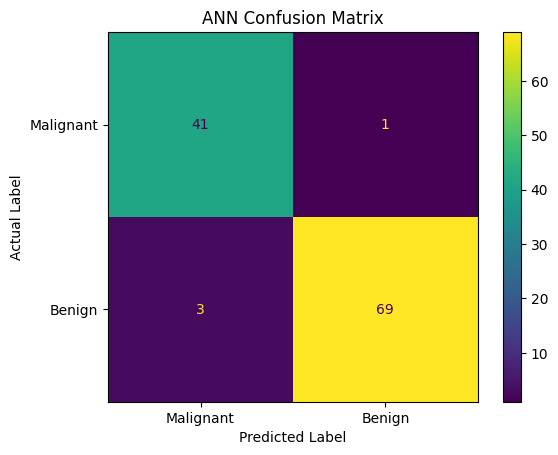

In [176]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

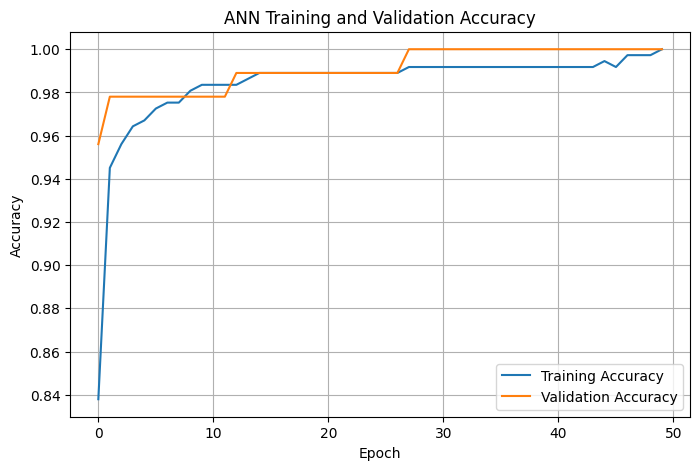

In [177]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")

plt.xticks()
plt.yticks()

plt.legend()
plt.grid(True)

plt.show()

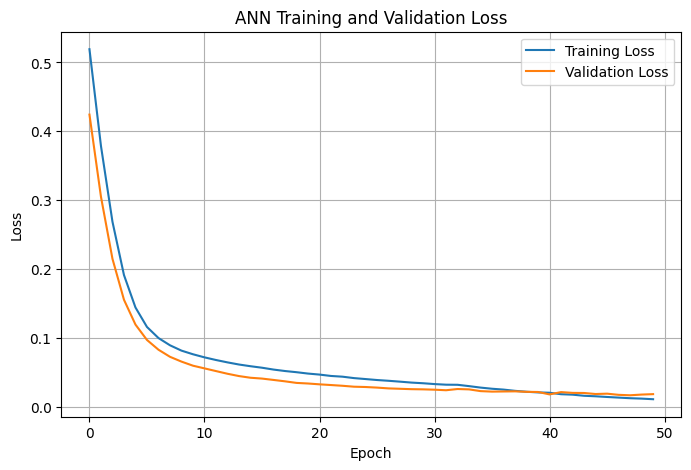

In [178]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")

plt.xticks()
plt.yticks()

plt.legend()
plt.grid(True)

plt.show()

In [179]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [180]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9649122807017544


In [181]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [182]:
model.save("ann_breast_cancer_model.keras")

In [183]:
from tensorflow.keras.models import load_model

loaded_model = load_model("ann_breast_cancer_model.keras")

In [184]:
test_loss, test_accuracy = loaded_model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9649 - loss: 0.1263 
Test Loss: 0.12626582384109497
Test Accuracy: 0.9649122953414917


In [185]:
!pip install pydot graphviz -q

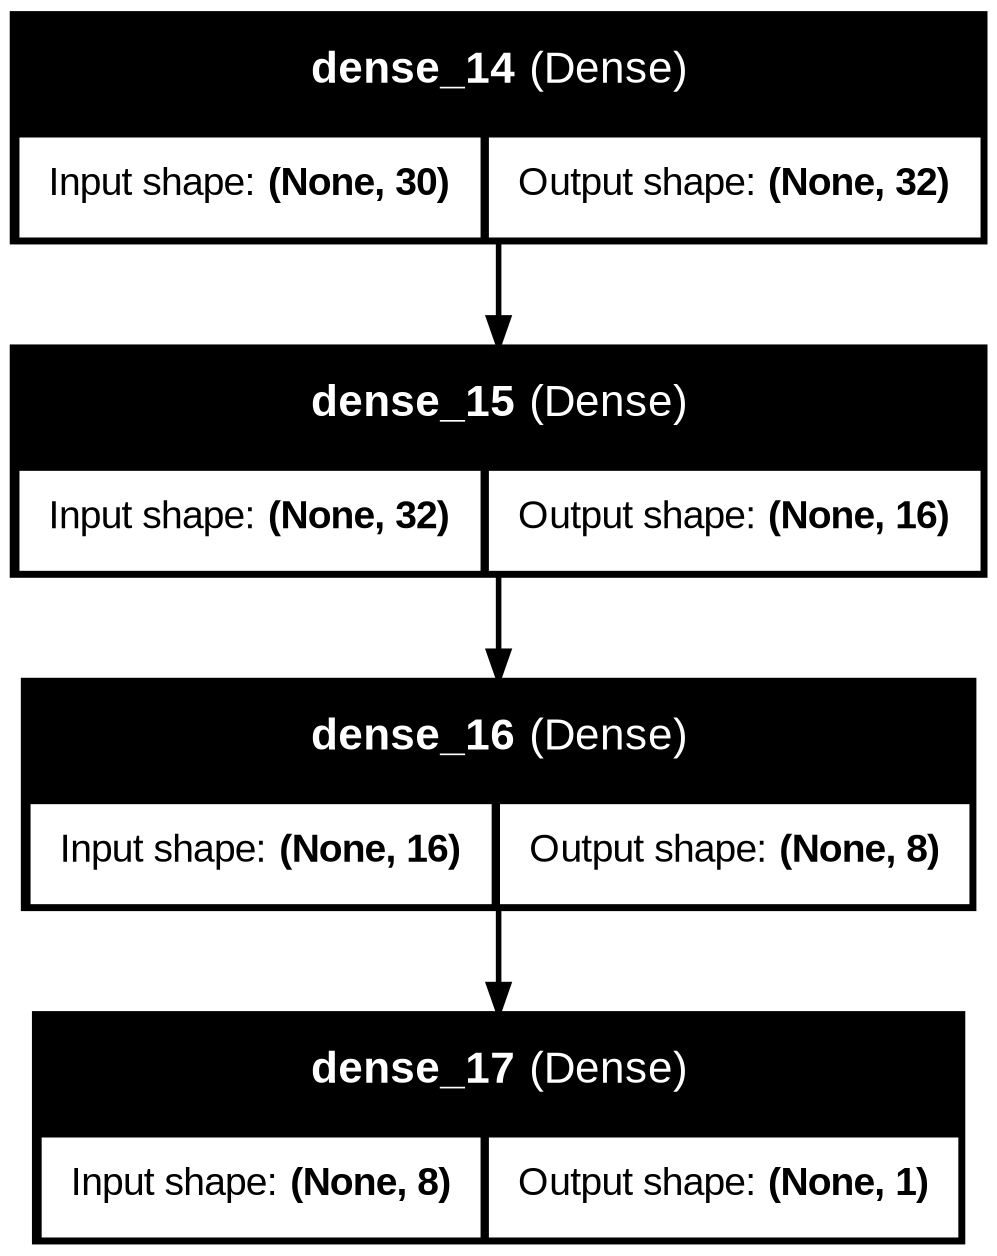

In [186]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="ann_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

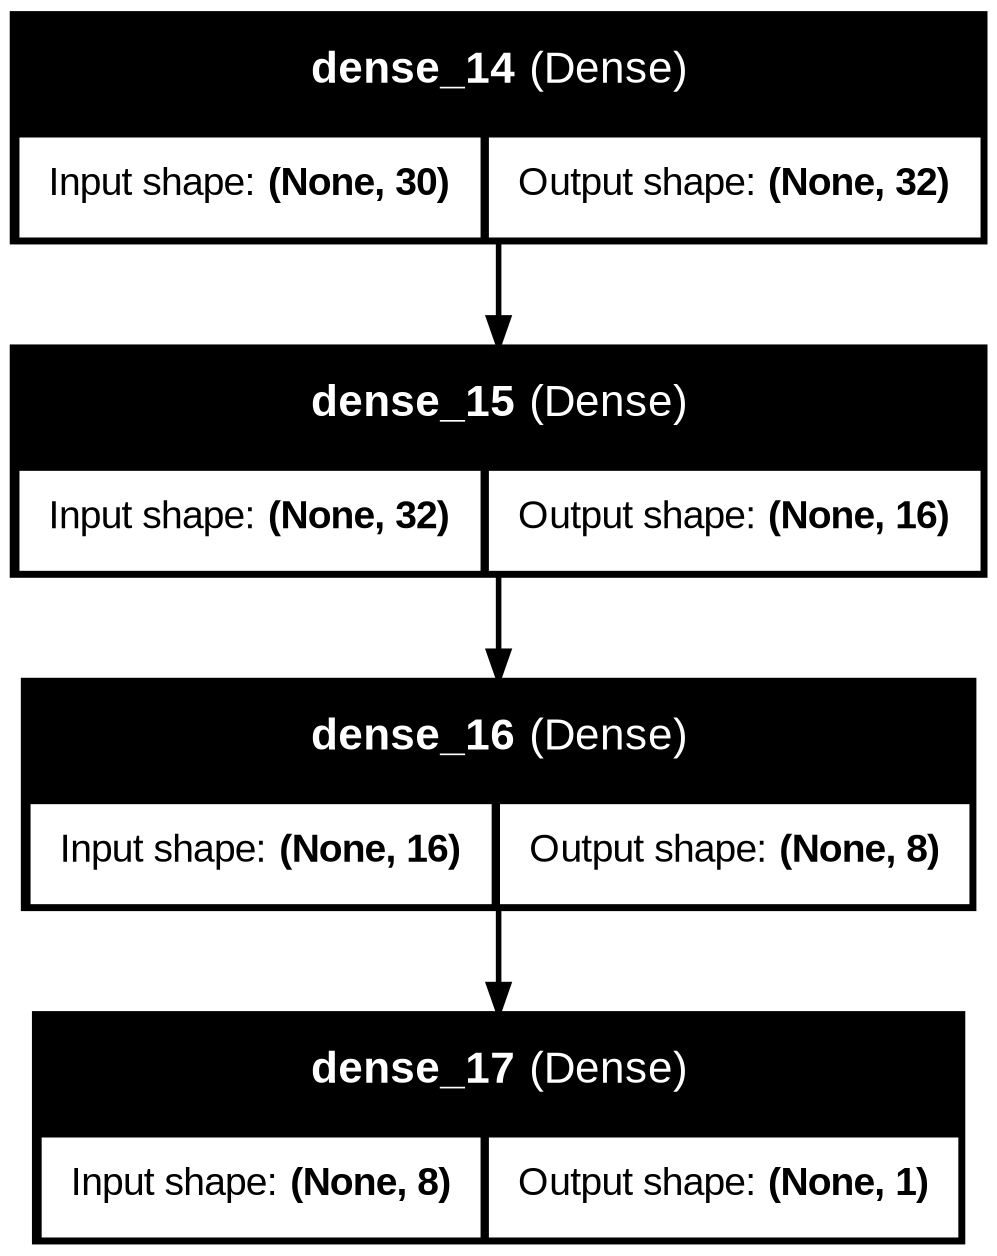

In [187]:
from IPython.display import Image, display

display(Image(filename="ann_architecture.png"))

In [188]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("ANN Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9824561403508771
ANN Accuracy: 0.9649122953414917


In [189]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "ANN"],
    "Accuracy": [lr_accuracy, accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.982456
1,ANN,0.964912


In [190]:
results.to_csv("model_comparison.csv", index=False)

In [191]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import Sequential

In [192]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing data:", X_test.shape)
print("Testing labels:", y_test.shape)

Training data: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing data: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [193]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [194]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

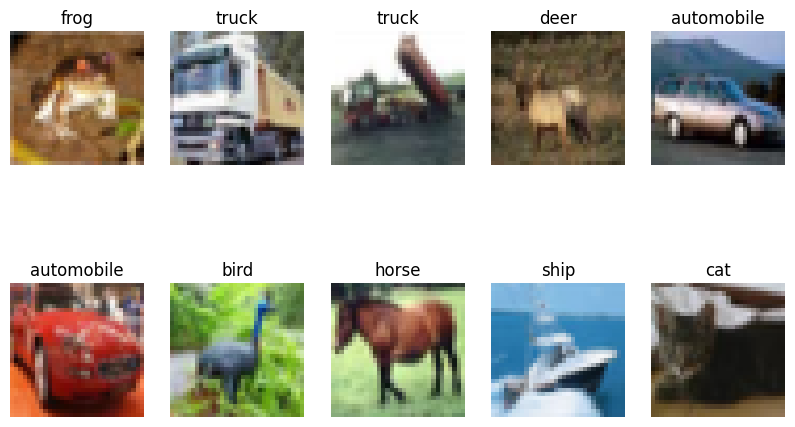

In [195]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

In [196]:
cnn_model = Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [197]:
cnn_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [198]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 113ms/step - accuracy: 0.4302 - loss: 1.5750 - val_accuracy: 0.5341 - val_loss: 1.3243
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.5623 - loss: 1.2336 - val_accuracy: 0.5860 - val_loss: 1.1908
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 72ms/step - accuracy: 0.6173 - loss: 1.0902 - val_accuracy: 0.6282 - val_loss: 1.0774
Epoch 4/10


In [ ]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test,
    y_test
)

print("CNN Test Accuracy:", cnn_accuracy)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predictions = cnn_model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

print("Predicted:", class_names[predicted_classes[0]])
print("Actual:", class_names[y_test[0][0]])

In [ ]:
plt.imshow(X_test[0])
plt.title(
    "Predicted: " + class_names[predicted_classes[0]] +
    "\nActual: " + class_names[y_test[0][0]]
)
plt.axis("off")
plt.show()

In [ ]:
cnn_model.save("cnn_cifar10_model.keras")

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(X_train.shape)
print(X_test.shape)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

cnn_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_model.summary()

In [ ]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_cnn = cnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test.flatten(),
    predicted_classes,
    target_names=class_names
))

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_cnn = confusion_matrix(
    y_test.flatten(),
    predicted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cnn,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cnn_precision = precision_score(
    y_test.flatten(),
    predicted_classes,
    average="weighted"
)

cnn_recall = recall_score(
    y_test.flatten(),
    predicted_classes,
    average="weighted"
)

cnn_f1 = f1_score(
    y_test.flatten(),
    predicted_classes,
    average="weighted"
)

print("CNN Accuracy :", cnn_accuracy)
print("CNN Precision:", cnn_precision)
print("CNN Recall   :", cnn_recall)
print("CNN F1 Score :", cnn_f1)

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Overfitting Check")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cnn_dropout = Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

In [ ]:
cnn_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
dropout_history = cnn_dropout.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
dropout_loss, dropout_accuracy = cnn_dropout.evaluate(
    X_test,
    y_test
)

print("Dropout CNN Accuracy:", dropout_accuracy)

In [ ]:
cnn_results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "CNN with Dropout"
    ],

    "Accuracy": [
        cnn_accuracy,
        dropout_accuracy
    ]
})

cnn_results

In [ ]:
import pandas as pd

In [ ]:
data_augmentation = Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)
])

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(5):

    augmented_image = data_augmentation(
        X_train[i:i+1],
        training=True
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_image[0])
    plt.axis("off")

plt.show()

In [ ]:
cnn_augmented = Sequential([

    data_augmentation,

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

In [ ]:
cnn_augmented.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
augmentation_history = cnn_augmented.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
augmentation_loss, augmentation_accuracy = cnn_augmented.evaluate(
    X_test,
    y_test
)

print("Augmented CNN Accuracy:", augmentation_accuracy)

In [133]:
all_cnn_results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "CNN + Dropout",
        "CNN + Data Augmentation + Dropout"
    ],

    "Accuracy": [
        cnn_accuracy,
        dropout_accuracy,
        augmentation_accuracy
    ]
})

all_cnn_results

,Model,Accuracy
0,Basic CNN,0.6889
1,CNN + Dropout,0.6566
2,CNN + Data Augmentation + Dropout,0.5937


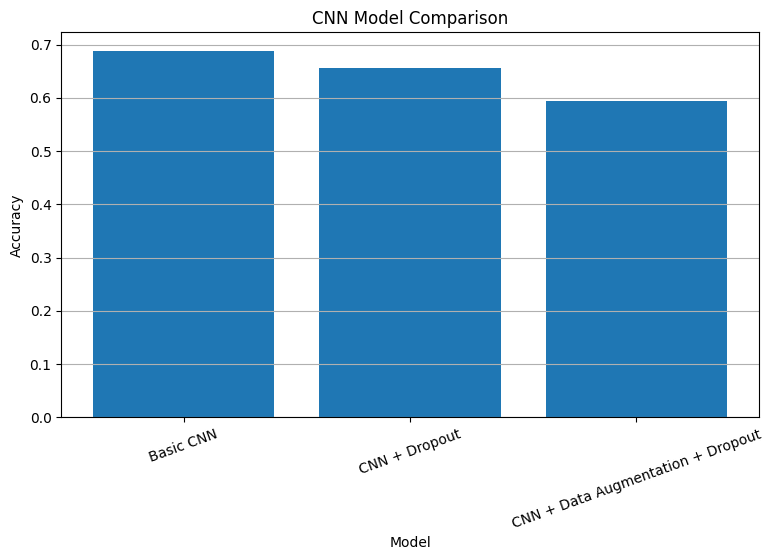

In [134]:
plt.figure(figsize=(9, 5))

plt.bar(
    all_cnn_results["Model"],
    all_cnn_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("CNN Model Comparison")

plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

In [135]:
cnn_augmented.save("final_cnn_model.keras")

In [ ]:
from tensorflow.keras.applications import MobileNetV2

In [ ]:
X_train_small = tf.image.resize(
    X_train[:10000],
    (96, 96)
)

y_train_small = y_train[:10000]

X_test_small = tf.image.resize(
    X_test[:2000],
    (96, 96)
)

y_test_small = y_test[:2000]

In [ ]:
X_train_small = tf.image.resize(
    X_train[:10000],
    (96, 96)
)

y_train_small = y_train[:10000]

X_test_small = tf.image.resize(
    X_test[:2000],
    (96, 96)
)

y_test_small = y_test[:2000]

In [ ]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

In [ ]:
base_model.trainable = False

In [ ]:
transfer_model = Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

In [ ]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [104]:
transfer_history = transfer_model.fit(
    X_train_small,
    y_train_small,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 518ms/step - accuracy: 0.5418 - loss: 1.3565 - val_accuracy: 0.7220 - val_loss: 0.8159
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 504ms/step - accuracy: 0.6906 - loss: 0.9171 - val_accuracy: 0.7525 - val_loss: 0.7295
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 568ms/step - accuracy: 0.7229 - loss: 0.7982 - val_accuracy: 0.7785 - val_loss: 0.7014
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 565ms/step - accuracy: 0.7559 - loss: 0.7286 - val_accuracy: 0.7740 - val_loss: 0.6852
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 505ms/step - accuracy: 0.7667 - loss: 0.6774 - val_accuracy: 0.7730 - val_loss: 0.6755


In [105]:
transfer_loss, transfer_accuracy = transfer_model.evaluate(
    X_test_small,
    y_test_small
)

print("Transfer Learning Accuracy:", transfer_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 183ms/step - accuracy: 0.7720 - loss: 0.6474
Transfer Learning Accuracy: 0.7720000147819519


In [106]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "ANN",
        "Basic CNN",
        "CNN + Dropout",
        "CNN + Augmentation + Dropout",
        "Transfer Learning"
    ],

    "Accuracy": [
        lr_accuracy,
        accuracy,
        cnn_accuracy,
        dropout_accuracy,
        augmentation_accuracy,
        transfer_accuracy
    ]
})

final_results

,Model,Accuracy
0,Logistic Regression,0.982456
1,ANN,0.956140
2,Basic CNN,0.688900
3,CNN + Dropout,0.656600
4,CNN + Augmentation + Dropout,0.593700
5,Transfer Learning,0.772000


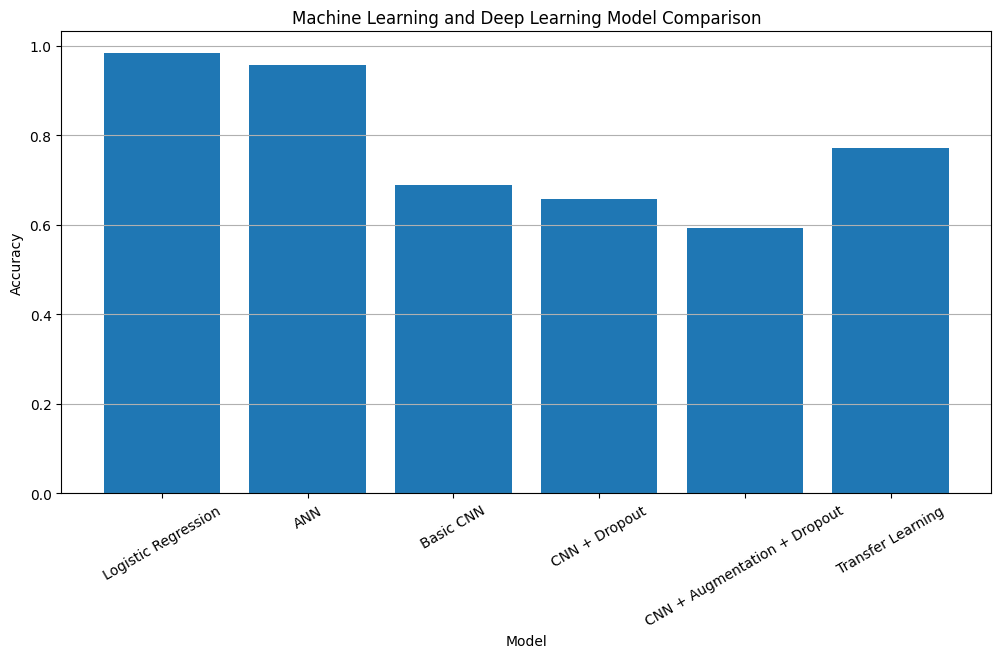

In [107]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Machine Learning and Deep Learning Model Comparison")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [108]:
final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

In [109]:
transfer_model.save(
    "transfer_learning_model.keras"
)

In [110]:
final_predictions = cnn_augmented.predict(X_test)

final_pred_classes = np.argmax(
    final_predictions,
    axis=1
)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Predictions generated successfully.


In [111]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.flatten(),
        final_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.66      0.62      0.64      1000
  automobile       0.62      0.82      0.71      1000
        bird       0.60      0.33      0.43      1000
         cat       0.47      0.39      0.43      1000
        deer       0.66      0.35      0.45      1000
         dog       0.63      0.41      0.50      1000
        frog       0.60      0.76      0.67      1000
       horse       0.56      0.72      0.63      1000
        ship       0.64      0.80      0.71      1000
       truck       0.54      0.75      0.63      1000

    accuracy                           0.59     10000
   macro avg       0.60      0.59      0.58     10000
weighted avg       0.60      0.59      0.58     10000



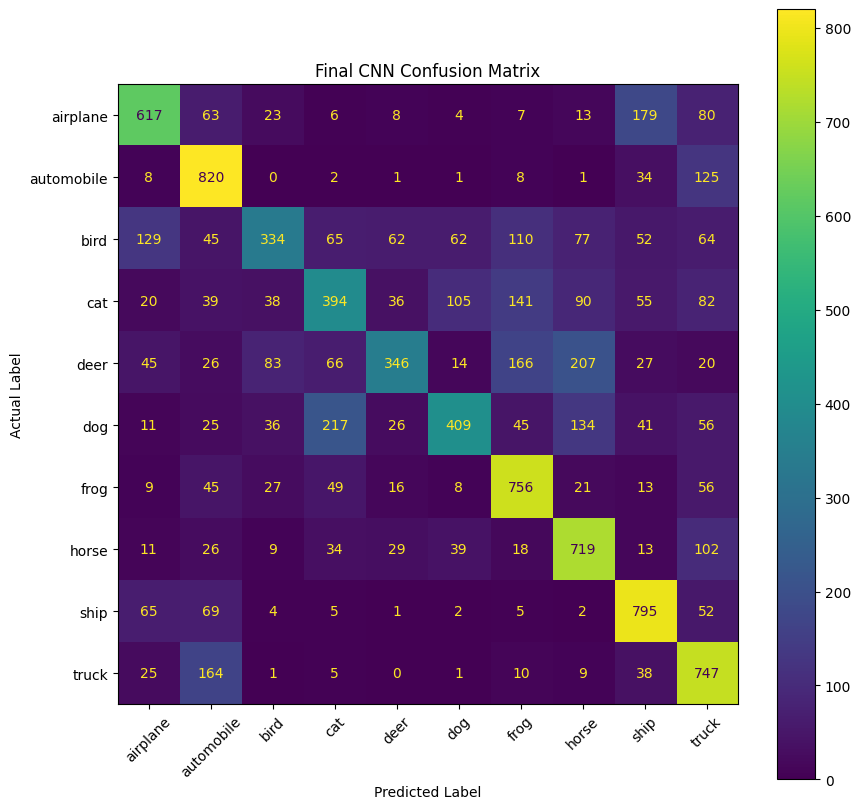

In [112]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_cm = confusion_matrix(
    y_test.flatten(),
    final_pred_classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Final CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

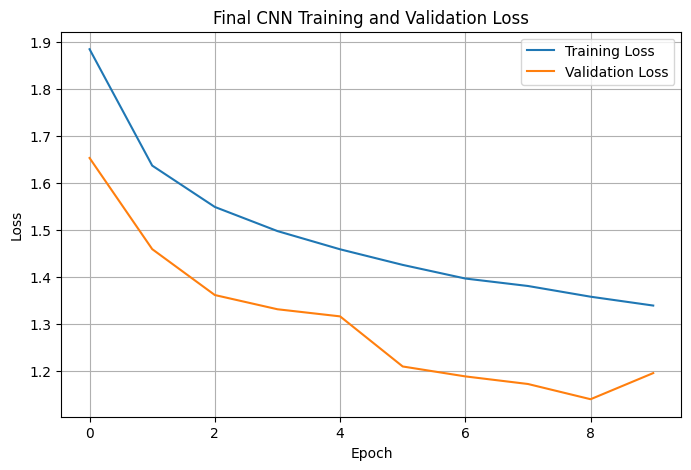

In [113]:
plt.figure(figsize=(8, 5))

plt.plot(
    augmentation_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    augmentation_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final CNN Training and Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [114]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

final_accuracy = accuracy_score(
    y_test.flatten(),
    final_pred_classes
)

final_precision = precision_score(
    y_test.flatten(),
    final_pred_classes,
    average="weighted"
)

final_recall = recall_score(
    y_test.flatten(),
    final_pred_classes,
    average="weighted"
)

final_f1 = f1_score(
    y_test.flatten(),
    final_pred_classes,
    average="weighted"
)

print("Final CNN Accuracy :", final_accuracy)
print("Final CNN Precision:", final_precision)
print("Final CNN Recall   :", final_recall)
print("Final CNN F1 Score :", final_f1)

Final CNN Accuracy : 0.5937
Final CNN Precision: 0.5978225547729958
Final CNN Recall   : 0.5937
Final CNN F1 Score : 0.5784737992012363


In [115]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "ANN",
        "Basic CNN",
        "CNN + Dropout",
        "CNN + Augmentation + Dropout",
        "Transfer Learning"
    ],

    "Accuracy": [
        lr_accuracy,
        accuracy,
        cnn_accuracy,
        dropout_accuracy,
        final_accuracy,
        transfer_accuracy
    ]
})

final_results

,Model,Accuracy
0,Logistic Regression,0.982456
1,ANN,0.956140
2,Basic CNN,0.688900
3,CNN + Dropout,0.656600
4,CNN + Augmentation + Dropout,0.593700
5,Transfer Learning,0.772000


In [116]:
final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final results saved.")

Final results saved.


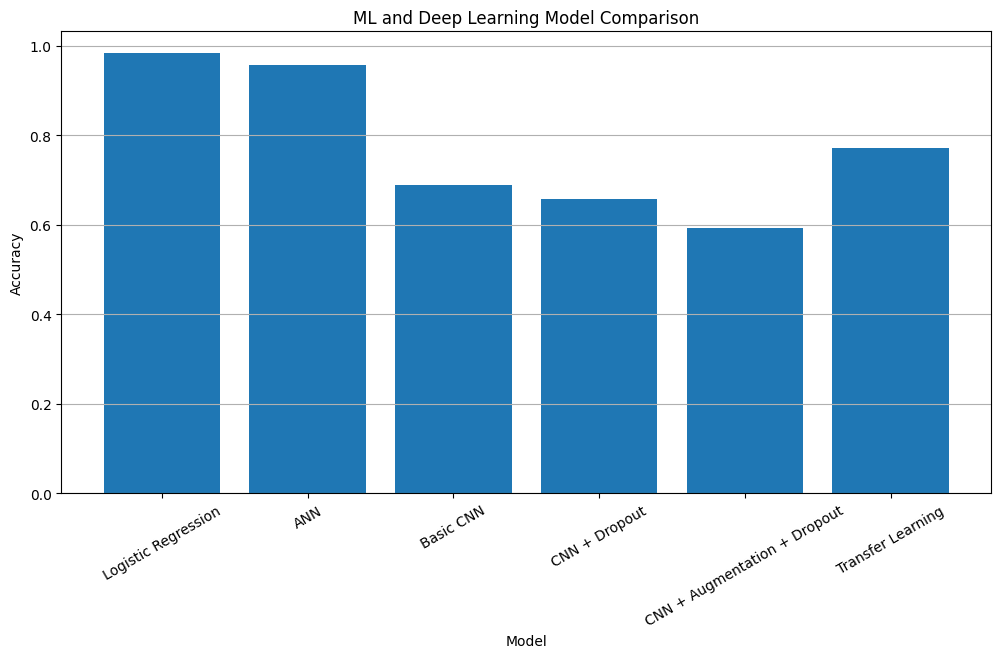

In [117]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("ML and Deep Learning Model Comparison")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

In [118]:
model.save("ann_breast_cancer_model.keras")

In [119]:
cnn_model.save("basic_cnn_cifar10.keras")

In [120]:
cnn_dropout.save("cnn_dropout_cifar10.keras")

In [121]:
cnn_augmented.save("final_cnn_cifar10.keras")

In [122]:
transfer_model.save("transfer_learning_cifar10.keras")

In [123]:
import os

for file in os.listdir():
    if file.endswith(".keras") or file.endswith(".csv"):
        print(file)

final_cnn_cifar10.keras
model_comparison.csv
transfer_learning_cifar10.keras
ann_breast_cancer_model.keras
transfer_learning_model.keras
final_model_comparison.csv
cnn_dropout_cifar10.keras
cnn_cifar10_model.keras
basic_cnn_cifar10.keras
final_cnn_model.keras


In [124]:
!pip install pydot graphviz -q

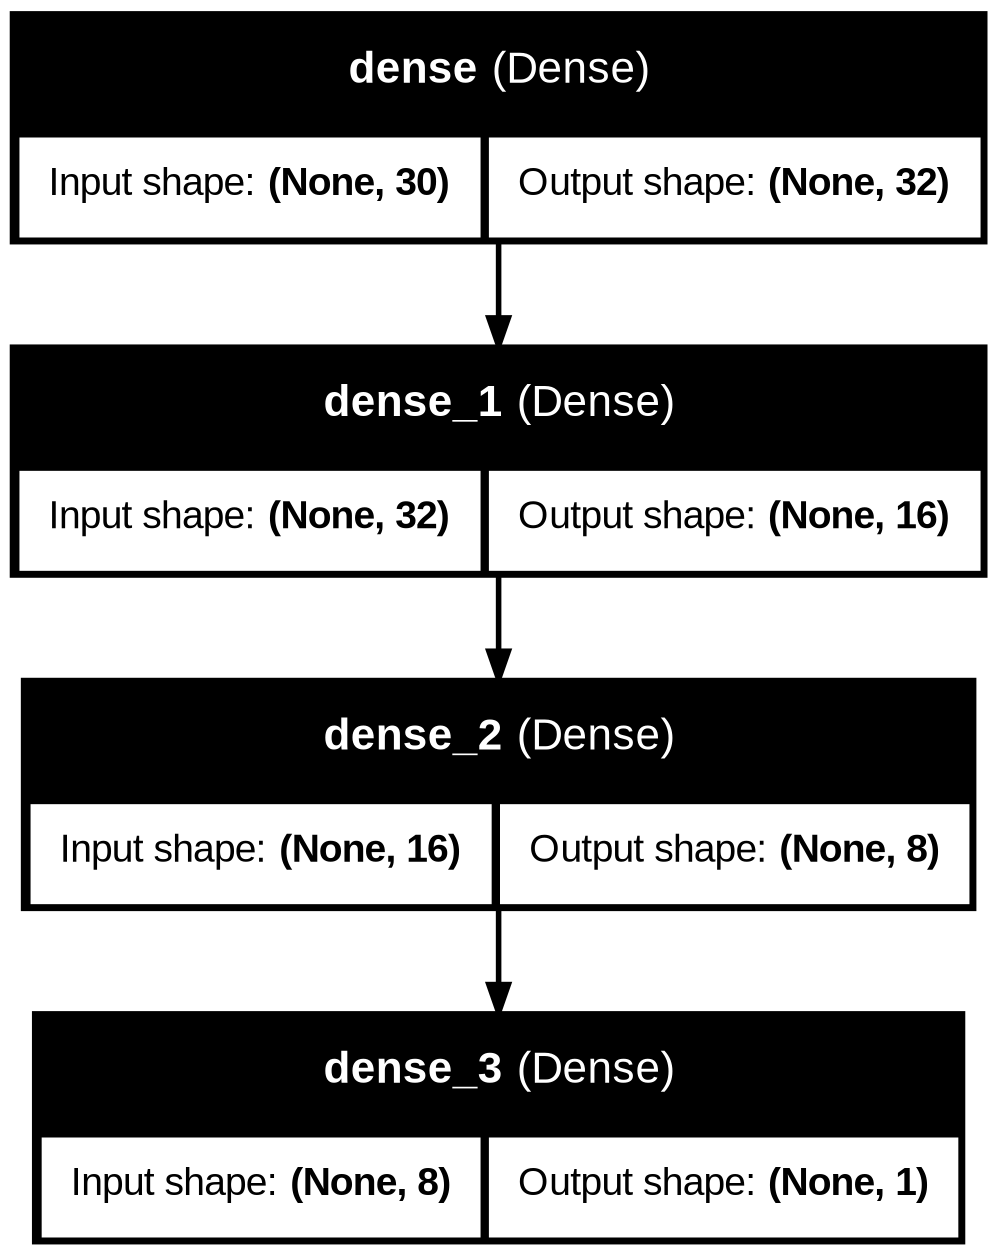

In [125]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="ann_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

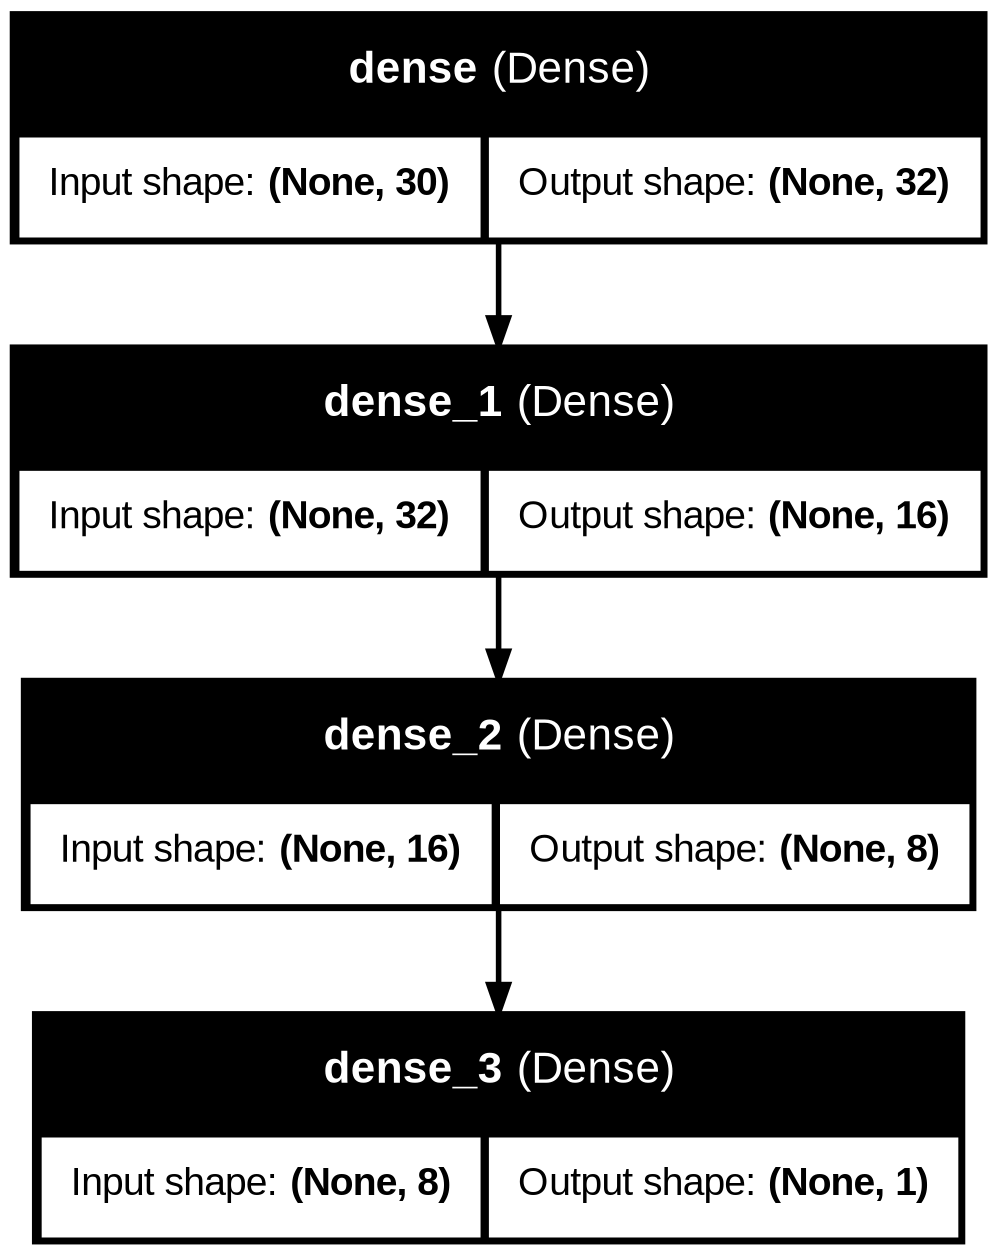

In [126]:
from IPython.display import Image, display

display(
    Image(
        filename="ann_architecture.png"
    )
)

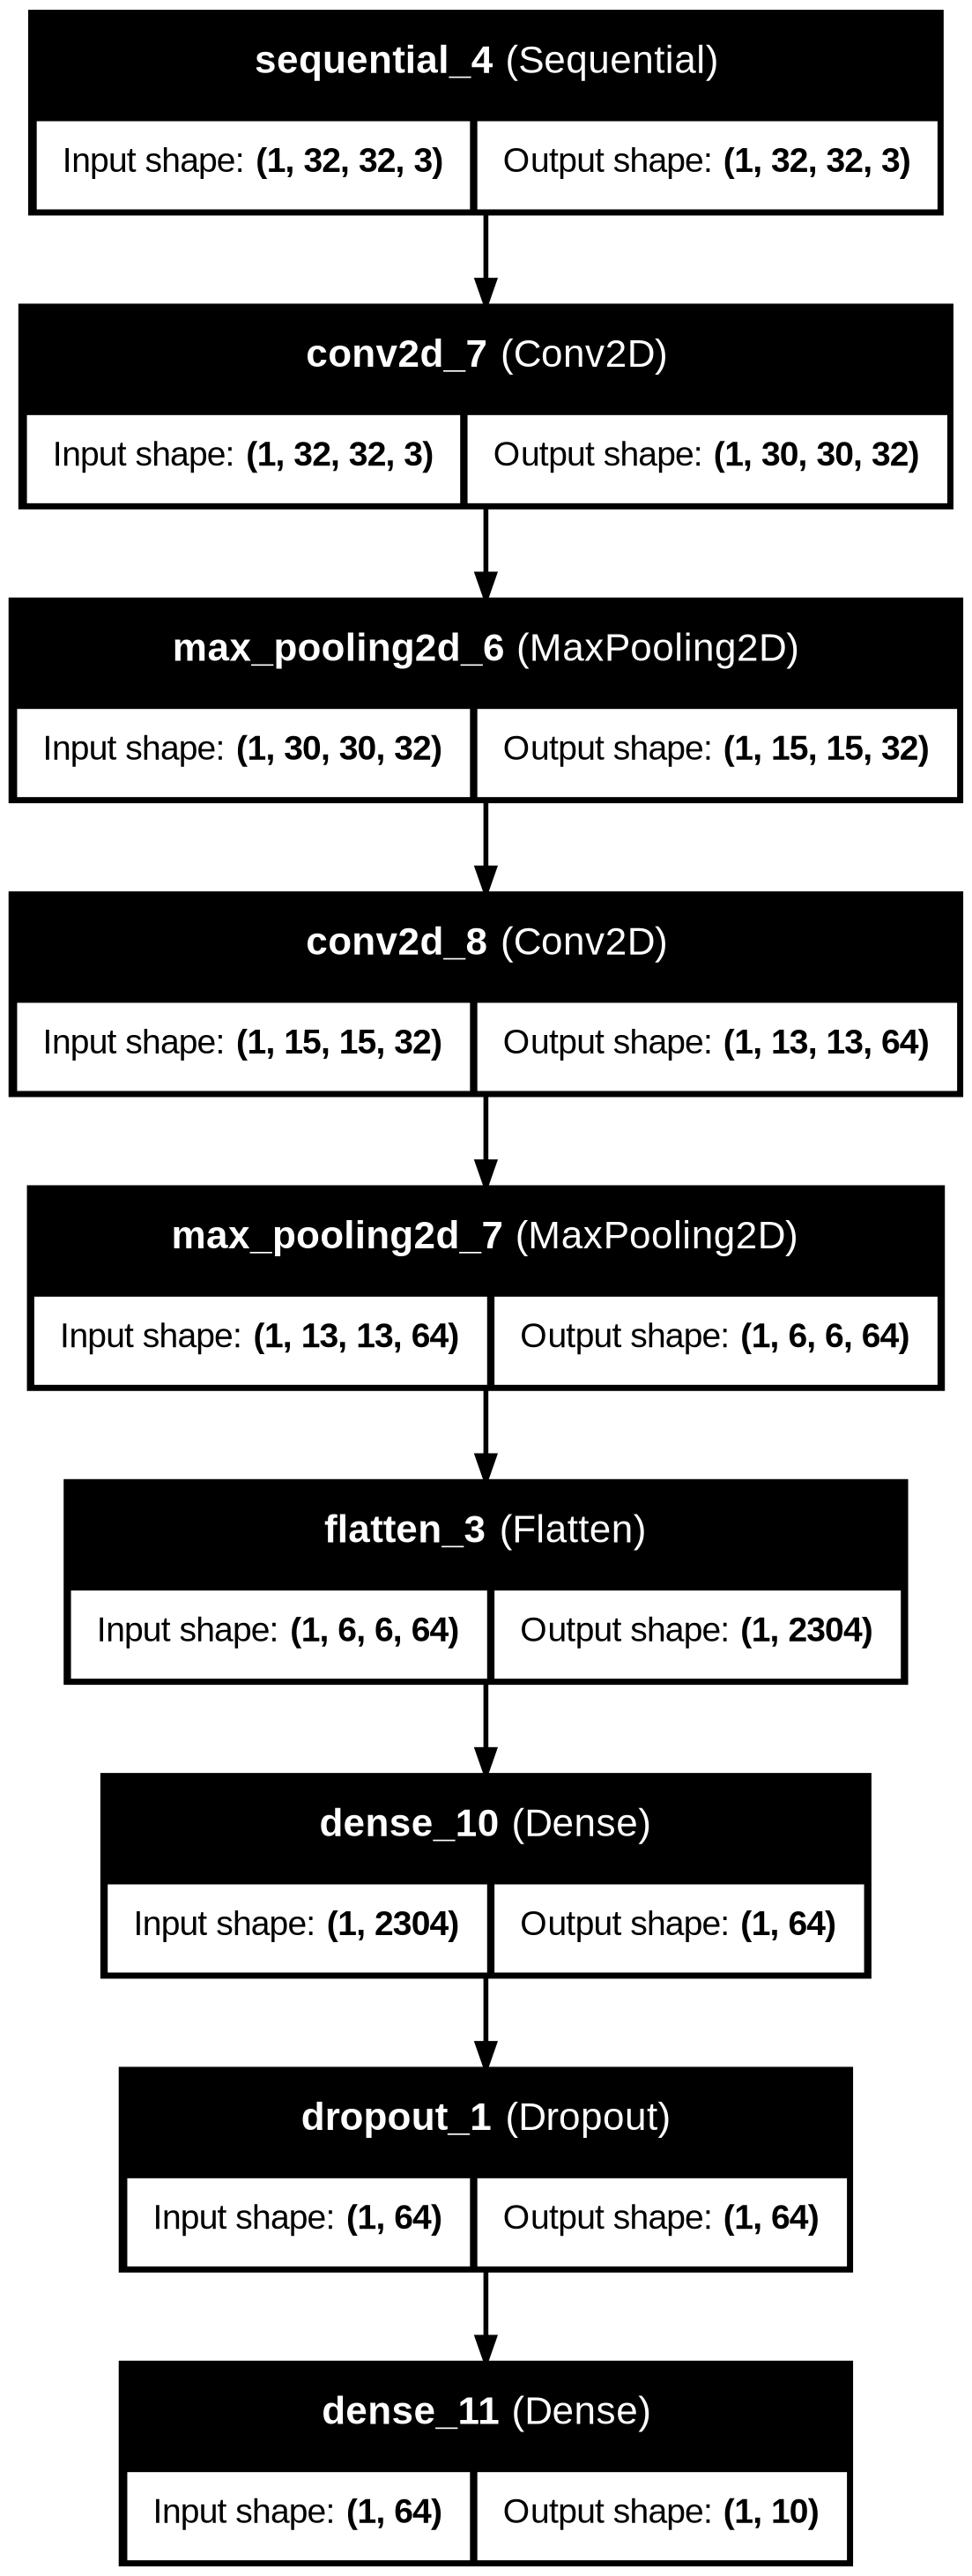

In [127]:
plot_model(
    cnn_augmented,
    to_file="cnn_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

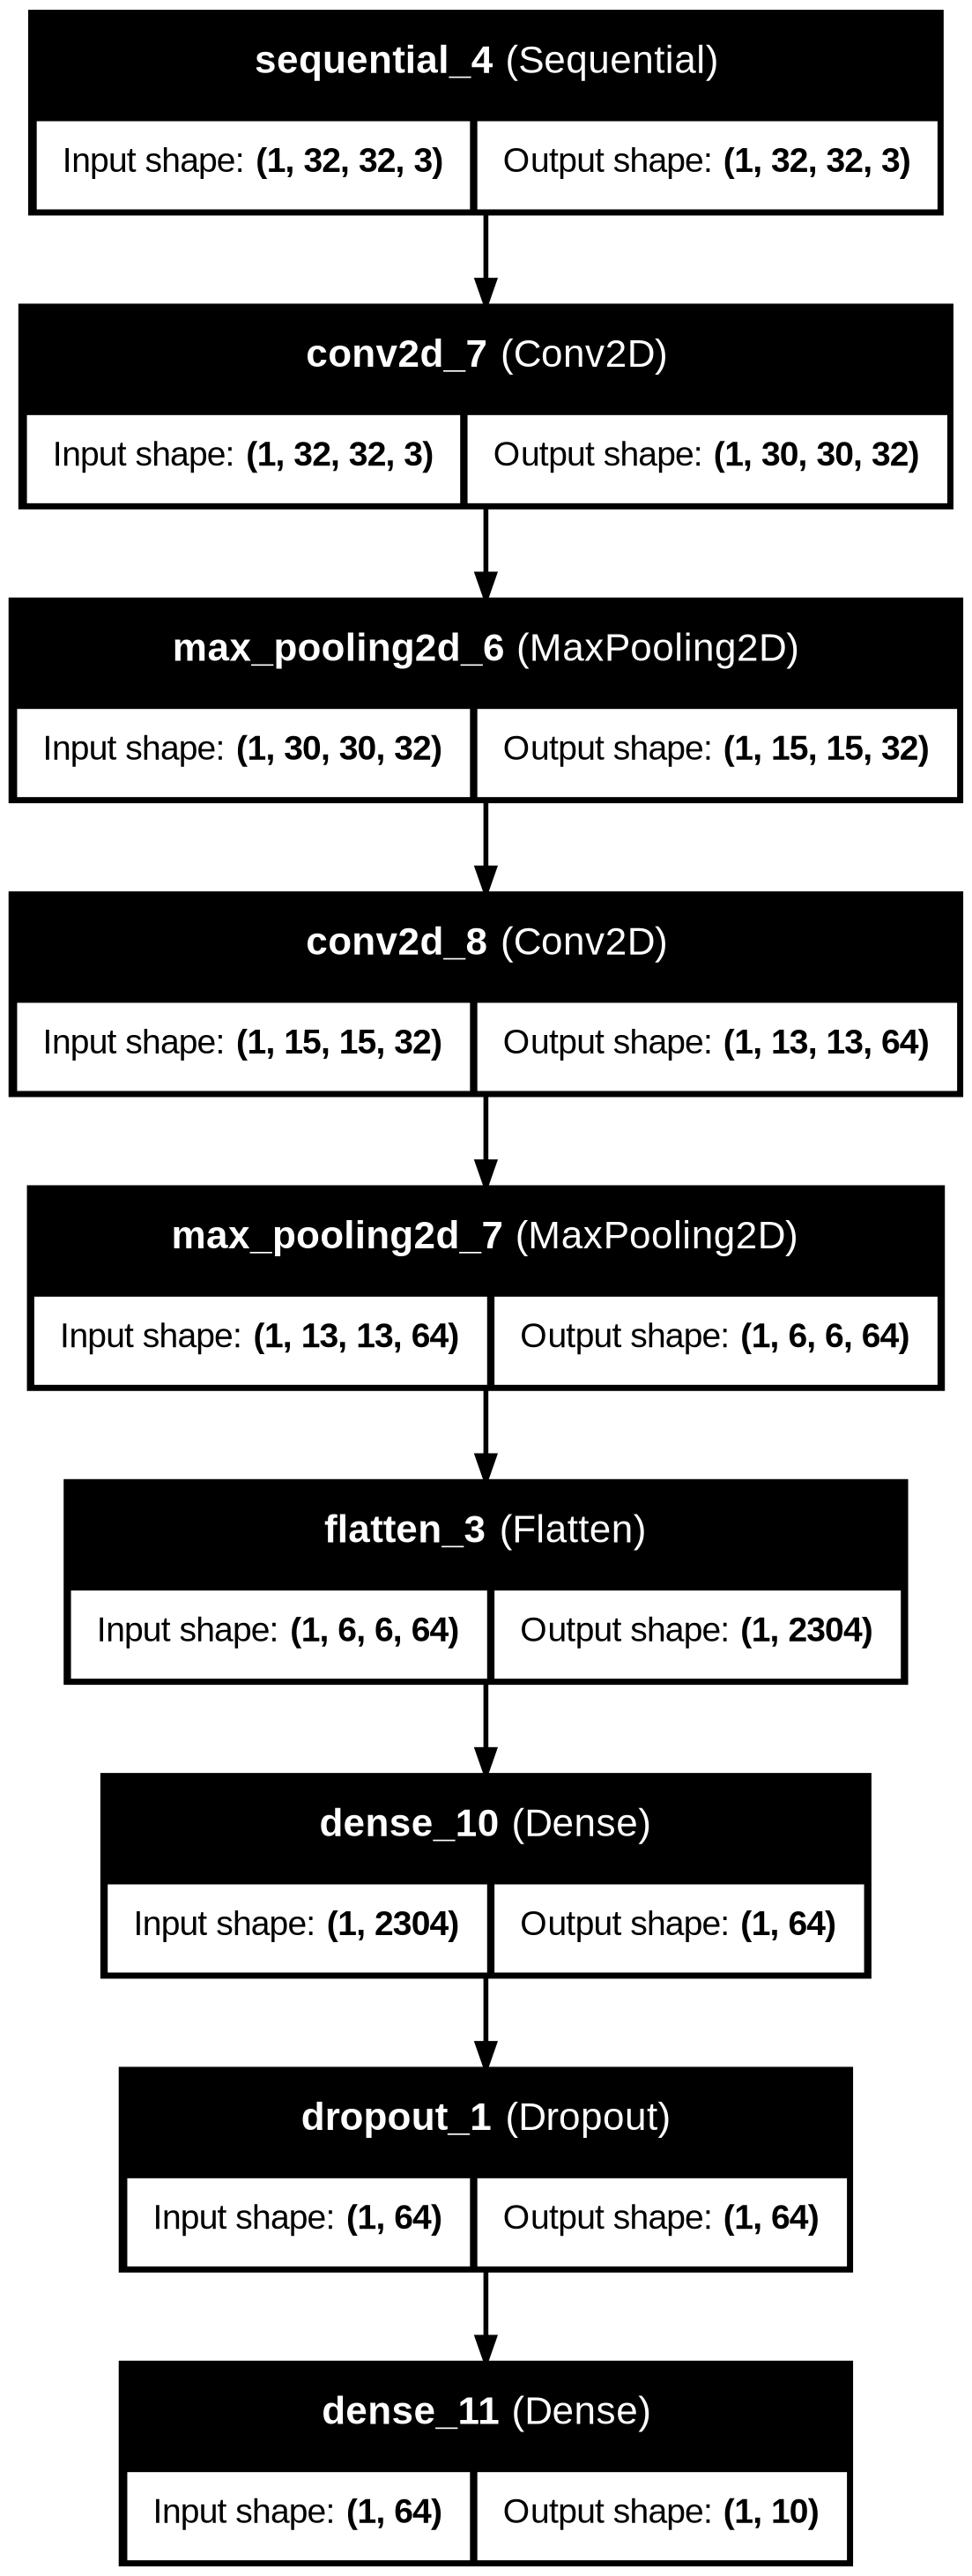

In [128]:

display(
    Image(
        filename="cnn_architecture.png"
    )
)

In [129]:
index = 10

image = X_test[index]

prediction = cnn_augmented.predict(
    np.expand_dims(image, axis=0)
)

predicted_class = np.argmax(prediction)

actual_class = y_test[index][0]

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[actual_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted: airplane
Actual: airplane


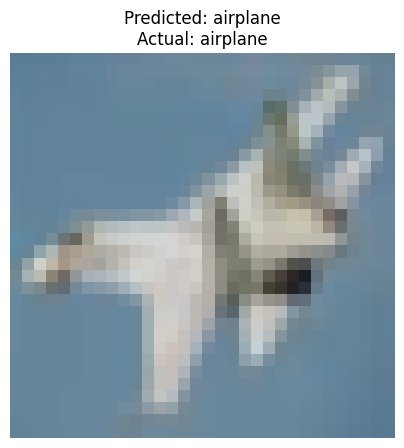

In [130]:
plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    "Predicted: " + class_names[predicted_class] +
    "\nActual: " + class_names[actual_class]
)

plt.axis("off")
plt.show()

In [131]:
import tensorflow
import sklearn
import pandas
import numpy
import matplotlib

print("tensorflow==", tensorflow.__version__)
print("scikit-learn==", sklearn.__version__)
print("pandas==", pandas.__version__)
print("numpy==", numpy.__version__)
print("matplotlib==", matplotlib.__version__)

tensorflow== 2.20.0
scikit-learn== 1.6.1
pandas== 2.2.3
numpy== 2.1.3
matplotlib== 3.10.0


In [132]:
import os

print("FINAL PROJECT FILES")
print("--------------------")

for file in os.listdir():
    print(file)

FINAL PROJECT FILES
--------------------
.config
ann_architecture.png
cnn_architecture.png
final_cnn_cifar10.keras
model_comparison.csv
transfer_learning_cifar10.keras
ann_breast_cancer_model.keras
transfer_learning_model.keras
final_model_comparison.csv
cnn_dropout_cifar10.keras
cnn_cifar10_model.keras
basic_cnn_cifar10.keras
final_cnn_model.keras
sample_data
